In [1]:
# we will use the same data set as Random Forest
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('Travel.csv')
df

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,204883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0
4884,204884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,3.0,Single,3.0,1,3,1,2.0,Executive,21212.0
4885,204885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0
4886,204886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,3.0,Single,3.0,0,5,0,2.0,Executive,20289.0


# Data Cleaning

In [3]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [4]:
df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [5]:
df['Gender'] = df['Gender'].replace('Fe Male', 'Female')
df['Gender'].value_counts()

Gender
Male      2916
Female    1972
Name: count, dtype: int64

In [6]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [7]:
df['MaritalStatus'] = df['MaritalStatus'].replace('Single','Unmarried')
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Unmarried    1598
Divorced      950
Name: count, dtype: int64

In [8]:
features_na = [f for f in df.columns if df[f].isnull().sum()>0]
features_na

['Age',
 'TypeofContact',
 'DurationOfPitch',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'NumberOfChildrenVisiting',
 'MonthlyIncome']

In [9]:
for f in features_na:
    print(f, ":     ", np.round(df[f].isnull().mean()*100,5))

Age :      4.62357
TypeofContact :      0.51146
DurationOfPitch :      5.13502
NumberOfFollowups :      0.92062
PreferredPropertyStar :      0.53191
NumberOfTrips :      2.86416
NumberOfChildrenVisiting :      1.35025
MonthlyIncome :      4.76678


In [10]:
df[features_na].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


## Imputing Null values <br>
1. Impute Median value for Age column<br>
2. Impute Mode for Type of Contract<br>
3. Impute Median for Duration of Pitch<br>
4. Impute Mode for NumberofFollowup as it is Discrete feature<br>
5. Impute Mode for PreferredPropertyStar<br>
6. Impute Median for NumberofTrips<br>
7. Impute Mode for NumberOfChildrenVisiting<br>
8. Impute Median for MonthlyIncome<br>

In [11]:
#Age
df.Age.fillna(df.Age.median(), inplace=True)

#TypeofContract
df.TypeofContact.fillna(df.TypeofContact.mode()[0], inplace=True)

#DurationOfPitch
df.DurationOfPitch.fillna(df.DurationOfPitch.median(), inplace=True)

#NumberOfFollowups
df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0], inplace=True)

#PreferredPropertyStar
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0], inplace=True)

#NumberOfTrips
df.NumberOfTrips.fillna(df.NumberOfTrips.median(), inplace=True)

#NumberOfChildrenVisiting
df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.mode()[0], inplace=True)

#MonthlyIncome
df.MonthlyIncome.fillna(df.MonthlyIncome.median(), inplace=True)

C:\Users\p3pra\AppData\Local\Temp\ipykernel_13040\3927510868.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Age.fillna(df.Age.median(), inplace=True)
C:\Users\p3pra\AppData\Local\Temp\ipykernel_13040\3927510868.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [12]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [13]:
df.drop('CustomerID',inplace=True,axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ProdTaken                 4888 non-null   int64  
 1   Age                       4888 non-null   float64
 2   TypeofContact             4888 non-null   object 
 3   CityTier                  4888 non-null   int64  
 4   DurationOfPitch           4888 non-null   float64
 5   Occupation                4888 non-null   object 
 6   Gender                    4888 non-null   object 
 7   NumberOfPersonVisiting    4888 non-null   int64  
 8   NumberOfFollowups         4888 non-null   float64
 9   ProductPitched            4888 non-null   object 
 10  PreferredPropertyStar     4888 non-null   float64
 11  MaritalStatus             4888 non-null   object 
 12  NumberOfTrips             4888 non-null   float64
 13  Passport                  4888 non-null   int64  
 14  PitchSat

# Feature Engineering

In [15]:
df['ToatlVisiting'] = df['NumberOfPersonVisiting'] + df['NumberOfChildrenVisiting']
df.drop(['NumberOfChildrenVisiting','NumberOfPersonVisiting'],inplace=True,axis=1)

In [16]:
num_feature = [f for f in df.columns if df[f].dtype != 'object']
cat_feature = [f for f in df.columns if df[f].dtype == 'O']
discrete_feature = [f for f in num_feature if len(df[f].unique()) <= 25]
continuous_feature = [f for f in num_feature if len(df[f].unique()) > 25]

In [23]:
from sklearn.model_selection import train_test_split
x = df.drop('ProdTaken',axis=1)
y = df['ProdTaken']

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.23,random_state=42)
x_train.shape, x_test.shape

((3763, 17), (1125, 17))

In [25]:
cat_feature = x.select_dtypes(include='object').columns
num_feature = x.select_dtypes(exclude='object').columns

In [26]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

oh_transformer = OneHotEncoder(drop='first')
scaler = StandardScaler()

preprocess = ColumnTransformer(
    [
        ('OneHotEncoder', oh_transformer, cat_feature),
        ('StandardScaler', scaler, num_feature)
    ]
    )

In [27]:
x_train = preprocess.fit_transform(x_train)


In [28]:
x_test = preprocess.transform(x_test)


# Training

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,precision_score,recall_score,f1_score,roc_curve,roc_auc_score,ConfusionMatrixDisplay

In [30]:
import sys
models = {
    "Logistic Regression" : LogisticRegression(),
    "Decision Tree" : DecisionTreeClassifier(),
    "Random Forest" : RandomForestClassifier(),
    "Gradient Boosting" : GradientBoostingClassifier(),
    "Adaboost" : AdaBoostClassifier()
}

np.printoptions(threshold=sys.maxsize)

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train,y_train)

    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)

    train_acc = accuracy_score(y_pred_train, y_train)
    train_precision = precision_score(y_pred_train, y_train)
    train_f1 = f1_score(y_pred_train, y_train, average='weighted')
    train_recall = recall_score(y_pred_train,y_train)
    train_roc_auc = roc_auc_score(y_pred_train,y_train)


    test_acc = accuracy_score(y_pred_test, y_test)
    test_precision = precision_score(y_pred_test, y_test)
    test_f1 = f1_score(y_pred_test, y_test, average='weighted')
    test_recall = recall_score(y_pred_test, y_test)
    test_roc_auc = roc_auc_score(y_pred_test, y_test)

    print(list(models.keys())[i])

    print("Model performance on Training data")
    print(f"Accuracy:   {train_acc}")
    print(f"Precision:   {train_precision}")
    print(f"Recall:   {train_recall}")
    print(f"F1 Score:   {train_f1}")
    print(f"ROC AUC Score:   {train_roc_auc}")
    print("-"*35)



    print("Model Performance on Test Data")
    
   
    print(f"Accuracy:   {test_acc}")
    print(f"Precision:   {test_precision}")
    print(f"Recall:   {test_recall}")
    print(f"F1 Score:   {test_f1}")
    print(f"ROC AUC Score:   {test_roc_auc}")

    print("="*35)
    print("\n")

Logistic Regression
Model performance on Training data
Accuracy:   0.8440074408716449
Precision:   0.302945301542777
Recall:   0.7058823529411765
F1 Score:   0.8702815142482019
ROC AUC Score:   0.7810580408038252
-----------------------------------
Model Performance on Test Data
Accuracy:   0.8417777777777777
Precision:   0.30434782608695654
Recall:   0.6494845360824743
F1 Score:   0.8659316576813737
ROC AUC Score:   0.7547033575354005


Decision Tree
Model performance on Training data
Accuracy:   1.0
Precision:   1.0
Recall:   1.0
F1 Score:   1.0
ROC AUC Score:   1.0
-----------------------------------
Model Performance on Test Data
Accuracy:   0.9066666666666666
Precision:   0.7536231884057971
Recall:   0.7428571428571429
F1 Score:   0.9064073127749847
ROC AUC Score:   0.8435597189695551


Random Forest
Model performance on Training data
Accuracy:   1.0
Precision:   1.0
Recall:   1.0
F1 Score:   1.0
ROC AUC Score:   1.0
-----------------------------------
Model Performance on Test Da

In [40]:
rf_params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, "auto", 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}
gradientboost_param = {
    "loss" : ['log_loss','deviance','exponential'],
    "criterion" : ['friedman_mse', 'mse','squared_error'],
    'min_samples_split' : [2,8,15,20],
    'n_estimators' : [100,200,500],
    'max_depth' : [5,8,10,11,None]
}

In [41]:
randomcv_models = [
                   ("RF", RandomForestClassifier(), rf_params),
                   ("Gradient Boost", GradientBoostingClassifier(), gradientboost_param)
                   ]

In [42]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=100,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1)
    random.fit(x_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits


c:\Users\p3pra\Desktop\code\practice\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
81 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
53 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\p3pra\Desktop\code\practice\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\p3pra\Desktop\code\practice\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\Users\p3pra\Desktop\code\practice\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_parameter_constraints(
  

Fitting 3 folds for each of 100 candidates, totalling 300 fits


c:\Users\p3pra\Desktop\code\practice\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
177 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
71 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\p3pra\Desktop\code\practice\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\p3pra\Desktop\code\practice\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\Users\p3pra\Desktop\code\practice\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_parameter_constraints(
 

---------------- Best Params for RF -------------------
{'n_estimators': 1000, 'min_samples_split': 2, 'max_features': 7, 'max_depth': None}
---------------- Best Params for Gradient Boost -------------------
{'n_estimators': 200, 'min_samples_split': 15, 'max_depth': None, 'loss': 'log_loss', 'criterion': 'squared_error'}


In [44]:
import sys
models = {
    "Gradient Boost" : GradientBoostingClassifier(n_estimators=200,loss='log_loss',criterion='squared_error', min_samples_split=15,max_depth=None)
}

np.printoptions(threshold=sys.maxsize)

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train,y_train)

    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)

    train_acc = accuracy_score(y_pred_train, y_train)
    train_precision = precision_score(y_pred_train, y_train)
    train_f1 = f1_score(y_pred_train, y_train, average='weighted')
    train_recall = recall_score(y_pred_train,y_train)
    train_roc_auc = roc_auc_score(y_pred_train,y_train)


    test_acc = accuracy_score(y_pred_test, y_test)
    test_precision = precision_score(y_pred_test, y_test)
    test_f1 = f1_score(y_pred_test, y_test, average='weighted')
    test_recall = recall_score(y_pred_test, y_test)
    test_roc_auc = roc_auc_score(y_pred_test, y_test)

    print(list(models.keys())[i])

    print("Model performance on Training data")
    print(f"Accuracy:   {train_acc}")
    print(f"Precision:   {train_precision}")
    print(f"Recall:   {train_recall}")
    print(f"F1 Score:   {train_f1}")
    print(f"ROC AUC Score:   {train_roc_auc}")
    print("-"*35)



    print("Model Performance on Test Data")
    
   
    print(f"Accuracy:   {test_acc}")
    print(f"Precision:   {test_precision}")
    print(f"Recall:   {test_recall}")
    print(f"F1 Score:   {test_f1}")
    print(f"ROC AUC Score:   {test_roc_auc}")

    print("="*35)
    print("\n")

Gradient Boost
Model performance on Training data
Accuracy:   1.0
Precision:   1.0
Recall:   1.0
F1 Score:   1.0
ROC AUC Score:   1.0
-----------------------------------
Model Performance on Test Data
Accuracy:   0.9546666666666667
Precision:   0.7874396135265701
Recall:   0.9588235294117647
F1 Score:   0.9564434801778542
ROC AUC Score:   0.9563751154912227




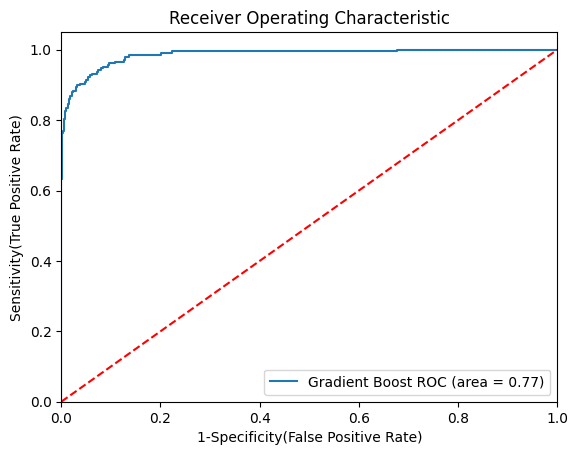

In [46]:
from sklearn.metrics import roc_auc_score,roc_curve
plt.figure()

# Add the models to the list that you want to view on the ROC plot
auc_models = [
{
    'label': 'Gradient Boost',
    "model"  : GradientBoostingClassifier(n_estimators=200,loss='log_loss',criterion='squared_error', min_samples_split=15,max_depth=None),
    'auc':  0.7706
},
    
]
# create loop through all model
for algo in auc_models:
    model = algo['model'] # select the model
    model.fit(x_train, y_train) # train the model
# Compute False postive rate, and True positive rate
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(x_test)[:,1])
# Calculate Area under the curve to display on the plot
    plt.plot(fpr, tpr, label='%s ROC (area = %0.2f)' % (algo['label'], algo['auc']))
# Custom settings for the plot 
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show() 